In [35]:
from keras.layers import Dense, Input, Flatten, TimeDistributed, Reshape, Multiply
from keras.models import Model, Sequential
import numpy as np
import pymongo
import tensorflow as tf
from CPMP_Layers.Layers import ConcatenationLayer, Reduction, Model_CPMP, LayerExpandOutput, Transformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [36]:
#************** | precision_for_multiclass() | ***************#
# El proposito de esta función es verificar si los valores    #
# predichos por un mecanismo de machine learning para         #
# clasificación multiclase están correctos o no.              #
#                                                             # 
# Input:                                                      #
#     - y_predict: Valores predichos por el mecanismo de      #
#                  machine learning.                          #
#     - y_test: Valores reales de cada caso.                  #
# Output:                                                     #
#     Retorna una proporción entre los valores predichos      #
#     correctamente sobre la cantidad total de casos.         #
def cosine_Similarity(y_predict, y_test):
    size = len(y_predict)
    suma = 0

    for i in range(size):
        result = np.dot(y_predict[i], y_test[i]) / (np.linalg.norm(y_predict[i]) * np.linalg.norm(y_test[i]))
        suma += result
    
    return suma / size

In [37]:
def connect_to_server(uri: str) -> None:
    """
    The purpose of this function is to establish 
    a connection between the MongoDB server and the program.

    Input:
        uri (string): The URL of the MongoDB server.
    """
    try: 
        client = pymongo.MongoClient(uri, serverSelectionTimeoutMS= 1000)
        client.server_info()
        print('Conection Success')

        return client
    
    except pymongo.errors.ServerSelectionTimeoutError as identifier:
        print('tiempo excedido' + identifier)

    except pymongo.errors.ConnectionFailure as conection_Error:
        print('Error al conectarse a mongodb' + conection_Error)

In [38]:
def load_data_mongo(collection):
    """
    The purpose of this function is to load data from MongoDB.

    Input:
        collection: The MongoDB client's database from which 
                    to load the data.
    """
    data = []
    labels = []

    for states in collection.find():
        data.append(states['State'])
        labels.append(states['Labels'])
    
    return np.stack(data), np.stack(labels)

In [39]:
def create_model(H: int):
    input_layer = Input(shape= (None, H + 1))
    model_cpmp_1 = Model_CPMP(num_heads= 5, key_dim= H + 1, activation= 'sigmoid')(input_layer)
    expand_layer = LayerExpandOutput()(model_cpmp_1)

    concat_layer = ConcatenationLayer()(input_layer)
    model_cpmp_2 = Model_CPMP(num_heads= 5, key_dim= H + 2, activation= 'sigmoid')
    distributed = TimeDistributed(model_cpmp_2)(concat_layer)
    flatten = Flatten()(distributed)

    multiply= Multiply()([expand_layer, flatten])
    reduction = Reduction()(multiply)

    model = Model(inputs= input_layer, outputs= reduction)
    model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['mse', 'mae'])

    return model

In [40]:
MONGO_URI_LOCAL = "mongodb://localhost:27017/"

In [41]:
client_local = connect_to_server(MONGO_URI_LOCAL)

base_de_datos = client_local['data_model_v2']
data_5x5, labels_5x5 = load_data_mongo(base_de_datos.data_5x5_v2)

client_local.close()

Conection Success


In [61]:
model = create_model(5)

In [59]:
X_train_5x5, X_test_5x5, y_train_5x5, y_test_5x5 = train_test_split(data_5x5[250000:], labels_5x5[250000:], 
                                                                    test_size= 0.2, random_state= 42)

In [62]:
history = model.fit(X_train_5x5, y_train_5x5, batch_size= 32, epochs= 50)

Epoch 1/50
6250/6250 [==============================] - 136s 19ms/step - loss: 0.2760 - mse: 0.0843 - mae: 0.1689
Epoch 2/50
6250/6250 [==============================] - 121s 19ms/step - loss: 0.2596 - mse: 0.0802 - mae: 0.1606
Epoch 3/50
6250/6250 [==============================] - 123s 20ms/step - loss: 0.2551 - mse: 0.0790 - mae: 0.1581
Epoch 4/50
6250/6250 [==============================] - 126s 20ms/step - loss: 0.2523 - mse: 0.0781 - mae: 0.1564
Epoch 5/50
6250/6250 [==============================] - 123s 20ms/step - loss: 0.2506 - mse: 0.0777 - mae: 0.1554
Epoch 6/50
6250/6250 [==============================] - 124s 20ms/step - loss: 0.2496 - mse: 0.0774 - mae: 0.1548
Epoch 7/50
6250/6250 [==============================] - 124s 20ms/step - loss: 0.2489 - mse: 0.0771 - mae: 0.1544
Epoch 8/50
6250/6250 [==============================] - 125s 20ms/step - loss: 0.2481 - mse: 0.0769 - mae: 0.1539
Epoch 9/50
6250/6250 [==============================] - 125s 20ms/step - loss: 0.2475 - 

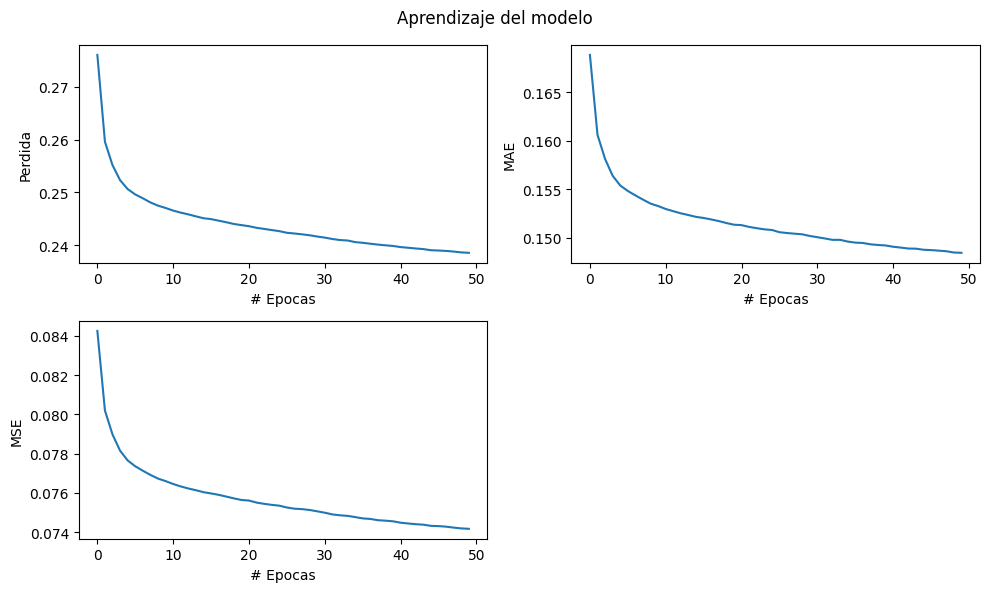

In [63]:
plt.figure(figsize= (10, 6))

plt.subplot(2, 2, 1)
plt.xlabel("# Epocas")
plt.ylabel("Perdida")
plt.plot(history.history['loss'])

plt.subplot(2, 2, 2)
plt.xlabel("# Epocas")
plt.ylabel("MAE")
plt.plot(history.history['mae'])

plt.subplot(2, 2, 3)
plt.xlabel("# Epocas")
plt.ylabel("MSE")
plt.plot(history.history['mse'])

plt.suptitle('Aprendizaje del modelo')
plt.tight_layout()
plt.show()

In [64]:
predict = model.predict(X_test_5x5)

1563/1563 [==============================] - 16s 9ms/step


In [65]:
results_1 = cosine_Similarity(predict, y_test_5x5)
results_2 = mean_absolute_error(y_test_5x5, predict)
results_3 = mean_squared_error(y_test_5x5, predict)

print(f'Precisión del modelo: {round(results_1 * 100, 3)}%')
print(f'Error Absoluto Medio: {round(results_2 * 100, 3)}%')
print(f'Error cuadratico medio: {round(results_3 * 100, 3)}%')

Precisión del modelo: 57.262%
Error Absoluto Medio: 15.334%
Error cuadratico medio: 7.389%


In [84]:
model.save('models/model_cpmp_5x5.keras')

In [66]:
from CPMP import cpmp_ml
from CPMP.cpmp_ml import Layout

In [67]:
def get_ann_state(layout: cpmp_ml.Layout) -> np.ndarray:
    S=len(layout.stacks) # Cantidad de stacks
    #matriz de stacks
    b = 2. * np.ones([S,layout.H + 1]) # Matriz normalizada
    for i,j in enumerate(layout.stacks):
        b[i][layout.H-len(j) + 1:] = [k/layout.total_elements for k in j]
        b[i][0] = layout.is_sorted_stack(i)
    b.shape=(S,(layout.H + 1))
    return b

In [68]:
def get_move(act, S=5,H=5):
  k=0
  for i in range(S):
    for j in range(S):
      if(i==j): continue
      if k==act: return (i,j)
      k+=1

In [69]:
def greedy_model(model, layouts, S= 5, H= 5, max_steps=10):
  from keras import backend as K
  costs = -np.ones(len(layouts))

  for steps in range(max_steps):
    x = []
    for i in range(len(layouts)):
      if layouts[i].unsorted_stacks==0: 
        if costs[i] ==-1: costs[i]=steps
        continue
      x.append(get_ann_state(layouts[i]))
    
    if len(x)==0: break
    actions = model.predict(np.stack(x), verbose=False)
    K.clear_session()
    k=0
    for i in range(len(layouts)):
      if costs[i] != -1: continue
      act = np.argmax(actions[k])
      move = get_move(act, S= S, H= H)
      layouts[i].move(move)
      k+=1
  return costs

In [70]:
from CPMP.cpmp_ml import generate_random_layout, read_file, greedys
from statistics import median, mean
from copy import deepcopy

def validate_model(model, S, H, N, verbose: bool = True, cvs_class=None):
    n = 1000

    lays = []
    if cvs_class is None:
        for i in range(n):
            lays.append(generate_random_layout(S,H,N))
    else:
        n=40
        for i in range(1,n+1):
            lay = read_file(f"benchmarks/CVS/{cvs_class}/data{cvs_class}-{i}.dat",5)
            lays.append(lay)

    lays1 = deepcopy(lays)
    costs1 = greedy_model(model, lays1, S= S, H= H, max_steps=N*2)
    costs2 = greedys(lays, max_steps= 80)

    valid_costs1 = [v for v in costs1 if v!=-1]
    valid_costs2 = [v for v in costs2 if v!=-1]

    results_model = len(valid_costs1) / n * 100.
    results_greedy = len(valid_costs2) / n * 100.

    if len(valid_costs1)>0:
        print(f"success ann model (%): {results_model}") 
        print(f"mean steps: {mean(valid_costs1)}")
        print(f"median steps: {median(valid_costs1)}")
        #print(f"stdesv steps: {stdev(valid_costs1)}")
        print(f"min steps: {min(valid_costs1)}")
        print(f"max steps: {max(valid_costs1)}")
        print('')
    if len(valid_costs2)==0:
        print("success heuristic (%):", results_greedy)
    else:
        print("success heuristic (%):", results_greedy, mean(valid_costs2))
        print(f"mean steps: {mean(valid_costs2)}")
        print(f"median steps: {median(valid_costs2)}")
        #print(f"stdesv steps: {stdev(valid_costs2)}")
        print(f"min steps: {min(valid_costs2)}")
        print(f"max steps: {max(valid_costs2)}")
        print('')

    return results_model, results_greedy

In [71]:
def eval_action(state, action, params):
    s_o, s_d = action
    g_s_d = state.gvalue(s_d)
    g_s_o = state.gvalue(s_o)
    c = state.stacks[s_o][-1]

    if state.is_BG_action(action):
        diff = g_s_d - g_s_o
        if state.reduced_stack == -1:
            return 100 - diff

    if state.reduced_stack==s_o or state.reduced_stack==-1:
        top_d = state.gvalue(s_d)

        if state.is_sorted_stack(s_d) and c <= top_d:  # xg
            eval_dest_stack = -top_d  # minimum difference between c and top_d is preferred
        elif not state.is_sorted_stack(s_d) and c >= top_d:  # xb
            eval_dest_stack = -10**params[0] + top_d  # minimum difference between c and top_d is preferred
        elif state.is_sorted_stack(s_d):  # xb
            eval_dest_stack = -10**params[1] - len(state.stacks[s_d])  # - top_d
        else:
            eval_dest_stack = -10**params[2] - 10**params[3]*len(state.stacks[s_d]) - top_d

        # Factor in remaining containers in the destination stack
        if len(state.stacks[s_d]) > 1:
            next_container = state.stacks[s_d][-2]
            if next_container > c:
                eval_dest_stack -= 10**params[4]  # Penalize this action


        stack_len_multiplier = 1 + len(state.stacks[s_o]) / state.H  # Factor in stack length dynamically
        return stack_len_multiplier * eval_dest_stack

    return float("-inf")

def greedy(state, basic=True, params=[2.0, 2.0, 4, 2.1, 2], max_steps=20) -> int:
    steps = 0
    while state.unsorted_stacks>0 and steps < max_steps:
        actions = state.get_actions()

        best_ev = float("-inf"); best_action=None
        for action in actions:
            ev = eval_action(state, action, params)
            if ev > best_ev:
              best_ev=ev
              best_action=action

        if best_action is not None:
            #print(best_ev,best_action)
            state.move(best_action)
            #print(state.stacks)
        else:
            return -1
        steps +=1

    if state.unsorted_stacks==0:
        return steps
    return -1

def get_actions(self):
    actions =[]
    for i in range(len(self.stacks)):
        for j in range(len(self.stacks)):
            if i!=j and len(self.stacks[i]) > 0 and len(self.stacks[j]) < self.H:
                    actions.append((i,j))
    return actions

def is_BG_action(self, action):
    s_o = action[0]; s_d = action[1]
    if (self.is_sorted_stack(s_o)==False
    and self.is_sorted_stack(s_d)==True
    and self.gvalue(s_o) <= self.gvalue(s_d)):
      return True

    else: return False

def greedys(layouts, max_steps= 20):
  costs = -np.ones(len(layouts))
  for k in range(len(layouts)):
    steps = greedy(layouts[k], max_steps= max_steps)
    costs[k]=steps
  return costs

In [72]:
#cpmp_ml.generate_data2 = generate_data2
cpmp_ml.greedy_model = greedy_model
cpmp_ml.get_ann_state = get_ann_state
cpmp_ml.get_move = get_move
cpmp_ml.greedys = greedys

In [73]:
#overwriting greedy v2

cpmp_ml.greedy=greedy
Layout.get_actions=get_actions
Layout.is_BG_action=is_BG_action

In [83]:
validate_model(model, 5, 5, 15)

success ann model (%): 96.2
mean steps: 10.658004158004157
median steps: 11.0
min steps: 2.0
max steps: 22.0

success heuristic (%): 100.0 12.169
mean steps: 12.169
median steps: 12.0
min steps: 2.0
max steps: 25.0



(96.2, 100.0)